# Mutual Fund Analytics - Performance & Risk Analytics

This notebook contains mathematical formulations, CAGR computations, Sharpe & Sortino ratios, OLS regressions for Alpha/Beta, Maximum Drawdown calculations, and a composite Fund Scorecard ranking.

Developed by Antigravity AI Coding Assistant.


In [1]:
import os
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

# Set aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

db_path = "bluestock_mf.db"


## 1. Daily Returns Distribution Validation

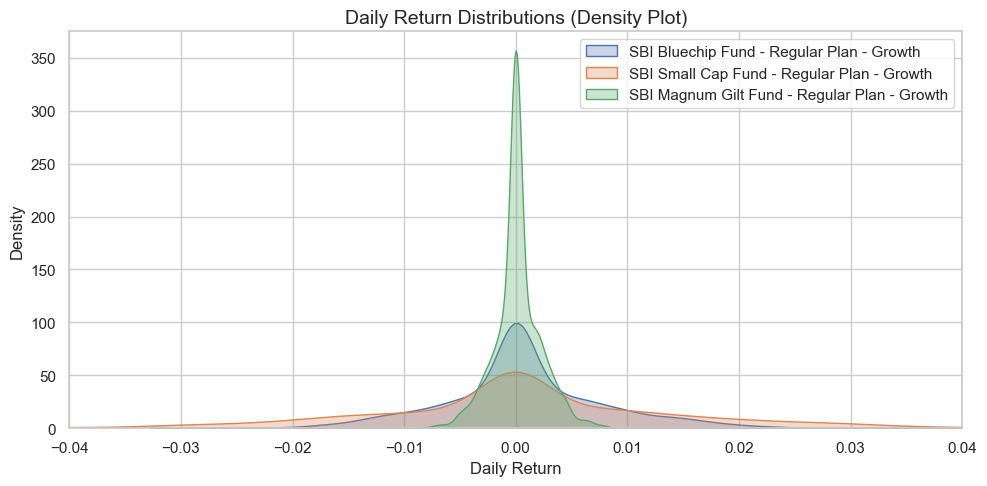

In [2]:
# Load NAV and compute daily returns
conn = sqlite3.connect(db_path)
df_nav = pd.read_sql_query("SELECT amfi_code, date, nav FROM fact_nav ORDER BY amfi_code, date", conn)
df_names = pd.read_sql_query("SELECT amfi_code, scheme_name FROM dim_fund", conn)
conn.close()

df_nav['date'] = pd.to_datetime(df_nav['date'])
df_nav = df_nav.sort_values(by=['amfi_code', 'date'])
df_nav['daily_return'] = df_nav.groupby('amfi_code')['nav'].pct_change()

# Plot return distribution for a few representative schemes
name_map = dict(zip(df_names['amfi_code'], df_names['scheme_name']))
selected_amfi = [119551, 119598, 119120]  # Bluechip, Small Cap, Gilt

plt.figure(figsize=(10, 5))
for amfi in selected_amfi:
    subset = df_nav[df_nav['amfi_code'] == amfi].dropna()
    sns.kdeplot(subset['daily_return'], fill=True, label=name_map[amfi], alpha=0.3)
plt.xlim(-0.04, 0.04)
plt.title("Daily Return Distributions (Density Plot)", fontsize=14)
plt.xlabel("Daily Return")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.savefig("reports/figures/returns_distribution.png", dpi=150)
plt.show()


## 2. CAGR Comparison Table

Shows computed annualized return performance over 1-Year, 3-Year, and 5-Year (Max history).


In [3]:
# Load computed scorecard
df_scorecard = pd.read_csv("fund_scorecard.csv")
print("CAGR Performance Metrics (Top 10 Funds):")
print(df_scorecard[['rank_overall', 'scheme_name', 'cagr_1yr', 'cagr_3yr', 'cagr_5yr_max']].head(10).to_string(index=False))


CAGR Performance Metrics (Top 10 Funds):
 rank_overall                                        scheme_name  cagr_1yr  cagr_3yr  cagr_5yr_max
            1      Mirae Asset Large Cap Fund - Regular - Growth  0.203607  0.340009      0.309741
            2           ICICI Pru Midcap Fund - Regular - Growth  0.296047  0.317775      0.328274
            3             Kotak Flexicap Fund - Regular - Growth  0.266571  0.295828      0.309075
            4 HDFC Mid-Cap Opportunities Fund - Regular - Growth  0.532324  0.324425      0.301232
            5          ICICI Pru Bluechip Fund - Direct - Growth  0.130643  0.324874      0.232951
            6                Axis Midcap Fund - Regular - Growth  0.222611  0.351118      0.282144
            7          SBI Bluechip Fund - Regular Plan - Growth  0.604373  0.304565      0.258047
            8      Mirae Asset Tax Saver Fund - Regular - Growth  0.397518  0.291789      0.319495
            9         SBI Small Cap Fund - Regular Plan - Growth  0.

## 3. Sharpe & Sortino Ratios Ranking

In [4]:
print("Risk-Adjusted Efficiency Metrics (Top 10 Funds):")
print(df_scorecard[['rank_overall', 'scheme_name', 'sharpe_ratio', 'sortino_ratio']].head(10).to_string(index=False))


Risk-Adjusted Efficiency Metrics (Top 10 Funds):
 rank_overall                                        scheme_name  sharpe_ratio  sortino_ratio
            1      Mirae Asset Large Cap Fund - Regular - Growth      1.068224       0.924139
            2           ICICI Pru Midcap Fund - Regular - Growth      0.883256       0.787729
            3             Kotak Flexicap Fund - Regular - Growth      0.965561       0.879201
            4 HDFC Mid-Cap Opportunities Fund - Regular - Growth      0.808268       0.710991
            5          ICICI Pru Bluechip Fund - Direct - Growth      0.714682       0.623031
            6                Axis Midcap Fund - Regular - Growth      0.730547       0.657796
            7          SBI Bluechip Fund - Regular Plan - Growth      0.860977       0.764479
            8      Mirae Asset Tax Saver Fund - Regular - Growth      0.919047       0.829746
            9         SBI Small Cap Fund - Regular Plan - Growth      0.711690       0.631332
           

## 4. Alpha & Beta (OLS Regressions against Nifty 100)

In [5]:
# Display Alpha/Beta metrics
print("Alpha/Beta Statistics (Top 10 Funds):")
print(df_scorecard[['rank_overall', 'scheme_name', 'alpha', 'beta']].head(10).to_string(index=False))


Alpha/Beta Statistics (Top 10 Funds):
 rank_overall                                        scheme_name    alpha      beta
            1      Mirae Asset Large Cap Fund - Regular - Growth 0.269838  0.023684
            2           ICICI Pru Midcap Fund - Regular - Growth 0.292636  0.000549
            3             Kotak Flexicap Fund - Regular - Growth 0.273305 -0.022830
            4 HDFC Mid-Cap Opportunities Fund - Regular - Growth 0.271954  0.005104
            5          ICICI Pru Bluechip Fund - Direct - Growth 0.211948  0.016232
            6                Axis Midcap Fund - Regular - Growth 0.260767 -0.066265
            7          SBI Bluechip Fund - Regular Plan - Growth 0.232010 -0.031751
            8      Mirae Asset Tax Saver Fund - Regular - Growth 0.282704  0.018134
            9         SBI Small Cap Fund - Regular Plan - Growth 0.303370 -0.023196
           10      ABSL Frontline Equity Fund - Regular - Growth 0.213998  0.021086


## 5. Maximum Drawdown & Worst Drawdown Date Ranges

In [6]:
# Display drawdowns
print("Worst Maximum Drawdowns & Timelines (Top 10 Funds):")
print(df_scorecard[['rank_overall', 'scheme_name', 'max_drawdown', 'worst_drawdown_peak', 'worst_drawdown_trough', 'worst_drawdown_recovery']].head(10).to_string(index=False))


Worst Maximum Drawdowns & Timelines (Top 10 Funds):
 rank_overall                                        scheme_name  max_drawdown worst_drawdown_peak worst_drawdown_trough worst_drawdown_recovery
            1      Mirae Asset Large Cap Fund - Regular - Growth     -0.112657          2023-07-11            2023-10-20              2024-02-21
            2           ICICI Pru Midcap Fund - Regular - Growth     -0.181885          2024-10-24            2025-01-23              2025-03-07
            3             Kotak Flexicap Fund - Regular - Growth     -0.129740          2022-03-07            2022-04-13              2022-09-22
            4 HDFC Mid-Cap Opportunities Fund - Regular - Growth     -0.162172          2022-03-13            2022-05-12              2022-07-27
            5          ICICI Pru Bluechip Fund - Direct - Growth     -0.125883          2022-10-04            2023-05-30              2023-07-11
            6                Axis Midcap Fund - Regular - Growth     -0.209609

## 6. Composite Fund Scorecard

In [7]:
print("Composite Fund Scorecard (Top 10 Funds):")
print(df_scorecard[['rank_overall', 'scheme_name', 'category', 'composite_score']].head(10).to_string(index=False))


Composite Fund Scorecard (Top 10 Funds):
 rank_overall                                        scheme_name category  composite_score
            1      Mirae Asset Large Cap Fund - Regular - Growth   Equity          86.2500
            2           ICICI Pru Midcap Fund - Regular - Growth   Equity          82.8750
            3             Kotak Flexicap Fund - Regular - Growth   Equity          82.0000
            4 HDFC Mid-Cap Opportunities Fund - Regular - Growth   Equity          80.7500
            5          ICICI Pru Bluechip Fund - Direct - Growth   Equity          79.3750
            6                Axis Midcap Fund - Regular - Growth   Equity          78.2500
            7          SBI Bluechip Fund - Regular Plan - Growth   Equity          74.1875
            8      Mirae Asset Tax Saver Fund - Regular - Growth   Equity          73.6875
            9         SBI Small Cap Fund - Regular Plan - Growth   Equity          68.0000
           10      ABSL Frontline Equity Fund - R

## 7. Tracking Error & Benchmark Comparison Chart

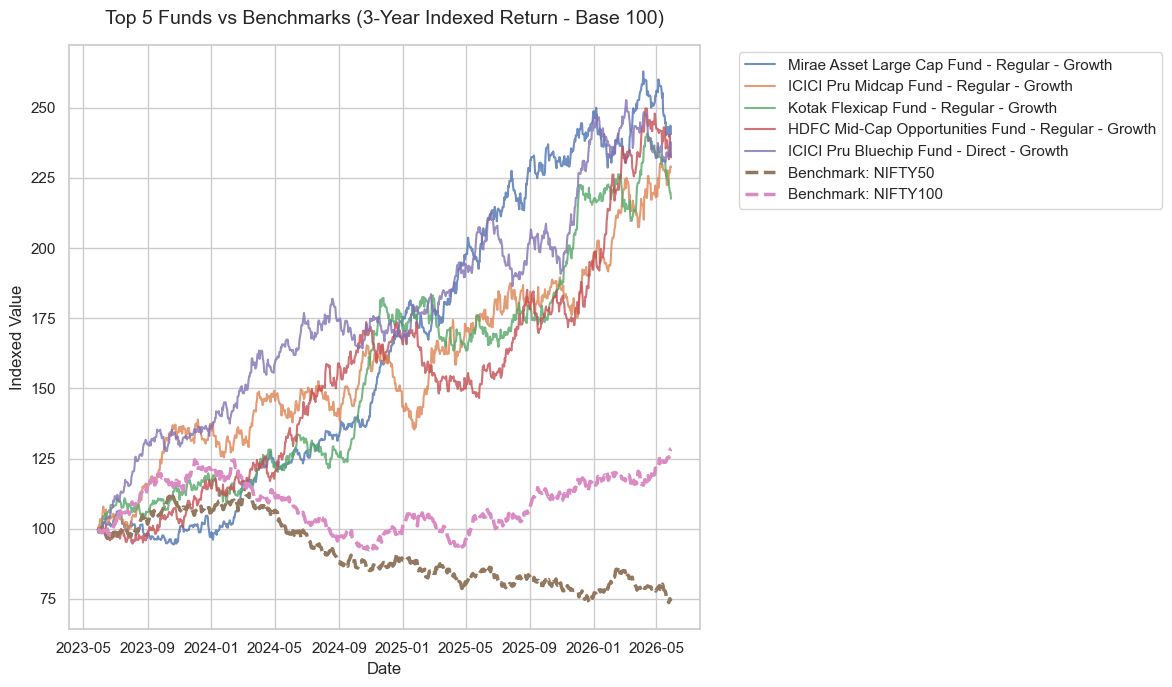

Computed Tracking Errors against NIFTY100:
  - Mirae Asset Large Cap Fund - Regular - Growth: 18.80%
  - ICICI Pru Midcap Fund - Regular - Growth: 23.27%
  - Kotak Flexicap Fund - Regular - Growth: 20.65%
  - HDFC Mid-Cap Opportunities Fund - Regular - Growth: 22.50%
  - ICICI Pru Bluechip Fund - Direct - Growth: 18.73%


In [8]:
# Plot Top 5 funds vs Nifty 50 and Nifty 100 over the last 3 years
conn = sqlite3.connect(db_path)
df_nav_full = pd.read_sql_query("SELECT amfi_code, date, nav FROM fact_nav", conn)
df_bench_full = pd.read_sql_query("SELECT date, index_name, close_value FROM benchmark_indices", conn)
conn.close()

df_nav_full['date'] = pd.to_datetime(df_nav_full['date'])
df_bench_full['date'] = pd.to_datetime(df_bench_full['date'])

# Extract top 5 amfi codes
top_5_amfi = df_scorecard.head(5)['amfi_code'].tolist()
top_5_names = df_scorecard.head(5)['scheme_name'].tolist()

# Define 3-year window
end_dt = df_nav_full['date'].max()
start_dt = end_dt - pd.DateOffset(years=3)

# Filter dates
df_nav_3yr = df_nav_full[(df_nav_full['date'] >= start_dt) & (df_nav_full['date'] <= end_dt)]
df_bench_3yr = df_bench_full[(df_bench_full['date'] >= start_dt) & (df_bench_full['date'] <= end_dt)]

# Compute indexed performance (Base 100 at start_dt)
plt.figure(figsize=(12, 7))

# Plot top 5 funds
tracking_errors = {}
nifty100_daily = df_bench_full[df_bench_full['index_name'] == 'NIFTY100'].sort_values('date').copy()
nifty100_daily['ret'] = nifty100_daily['close_value'].pct_change()
nifty100_daily_clean = nifty100_daily[['date', 'ret']].dropna()

for amfi, name in zip(top_5_amfi, top_5_names):
    fund_data = df_nav_3yr[df_nav_3yr['amfi_code'] == amfi].sort_values('date').copy()
    if fund_data.empty:
        continue
    # Indexing
    start_val = fund_data.iloc[0]['nav']
    fund_data['indexed_nav'] = (fund_data['nav'] / start_val) * 100.0
    plt.plot(fund_data['date'], fund_data['indexed_nav'], label=name, alpha=0.8)
    
    # Calculate daily return and tracking error
    fund_data['ret'] = fund_data['nav'].pct_change()
    merged = pd.merge(fund_data[['date', 'ret']], nifty100_daily_clean, on='date', how='inner')
    tracking_err = (merged['ret_x'] - merged['ret_y']).std() * np.sqrt(252)
    tracking_errors[name] = tracking_err

# Plot Nifty 50 and Nifty 100
for idx_name in ['NIFTY50', 'NIFTY100']:
    idx_data = df_bench_3yr[df_bench_3yr['index_name'] == idx_name].sort_values('date').copy()
    if idx_data.empty:
        continue
    start_val = idx_data.iloc[0]['close_value']
    idx_data['indexed_close'] = (idx_data['close_value'] / start_val) * 100.0
    plt.plot(idx_data['date'], idx_data['indexed_close'], label=f"Benchmark: {idx_name}", linewidth=2.5, linestyle='--')

plt.title("Top 5 Funds vs Benchmarks (3-Year Indexed Return - Base 100)", fontsize=14, pad=15)
plt.xlabel("Date")
plt.ylabel("Indexed Value")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Save PNG image deliverable at root and reports folder
plt.savefig("benchmark_comparison.png", dpi=150)
plt.savefig("reports/figures/benchmark_comparison.png", dpi=150)
plt.show()

print("Computed Tracking Errors against NIFTY100:")
for name, te in tracking_errors.items():
    print(f"  - {name}: {te * 100:.2f}%")
